# 🏠 House Price Prediction



## 1. Introduction



### Mục tiêu
Mục tiêu của dự án này là xây dựng một mô hình học máy để dự đoán giá nhà dựa trên các đặc điểm có sẵn trong tập dữ liệu.

### Ứng dụng thực tế
- Người mua nhà có thể ước tính giá hợp lý trước khi mua.
- Người bán có thể đặt giá cạnh tranh.
- Ngân hàng có thể đánh giá giá trị tài sản để cho vay thế chấp.

### Tập dữ liệu
Tập dữ liệu được lấy từ Kaggle (tập dữ liệu Giá nhà), chứa nhiều đặc điểm khác nhau mô tả nhà ở dân dụng và giá bán tương ứng của chúng.

### Loại bài toán
Đây là một **vấn đề Hồi quy**, trong đó mục tiêu là dự đoán một biến mục tiêu liên tục (`SalePrice`).



---



IMPORT LIBRARIES

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import wandb
from sklearn.model_selection import train_test_split

# Rule: Cố định seed để đảm bảo kết quả tái lập được [cite: 208]
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Cấu hình hiển thị biểu đồ
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
os.environ["WANDB_API_KEY"] = "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"

wandb.login()

WANDB_PROJECT = "house-price-prediction"
WANDB_ENTITY  = "Nhom_18"

print(f"Đã đăng nhập wandb thành công! Sẵn sàng tracking cho Project: {WANDB_PROJECT}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: 2351050199viet (Nhom_18) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Đã đăng nhập wandb thành công! Sẵn sàng tracking cho Project: house-price-prediction


## 2. Data Loading, Overview & Exploratory Data Analysis (EDA)

LOAD DATASET

In [3]:
# import os
# import pandas as pd
# from google.colab import drive

# # 1. Mount Drive
# if not os.path.ismount('/content/drive'):
#     drive.mount('/content/drive')

# # 2. Di chuyển vào thư mục dự án trên Drive
# project_path = '/content/drive/MyDrive/Colab Notebooks/BTL_HousePricePrediction'

# if os.path.exists(project_path):
#     os.chdir(project_path)
#     # Di chuyển vào thư mục notebooks để đúng cấu trúc ../data/
#     if os.path.exists("notebooks"):
#         os.chdir("notebooks")
#     print(f" Thư mục làm việc hiện tại: {os.getcwd()}")
# else:
#     print(f" LỖI: Không tìm thấy thư mục dự án tại {project_path}")

# # 3. Hàm load dữ liệu
def load_and_summarize_data(file_path):
    if not os.path.exists(file_path):
        print(f" LỖI: Không tìm thấy file tại: {os.path.abspath(file_path)}")
        return None
    try:
        df = pd.read_csv(file_path)
        print(f" Đã load thành công!")
        return df
    except Exception as e:
        print(f" Có lỗi khi đọc file: {e}")
        return None

# 4. Thực thi load data
data_path = "../data/train.csv"
df = load_and_summarize_data(data_path)

 Đã load thành công!


In [4]:
print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Kiểm tra dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# Thống kê cơ bản
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## Bước 1 - Phân tích biến mục tiêu (`SalePrice`)
Mục tiêu: kiểm tra normality của `SalePrice` bằng histogram + QQ-plot, đo `skewness`/`kurtosis` trước và sau log-transform.

Skewness trước log: 1.8809
Kurtosis trước log: 6.5098


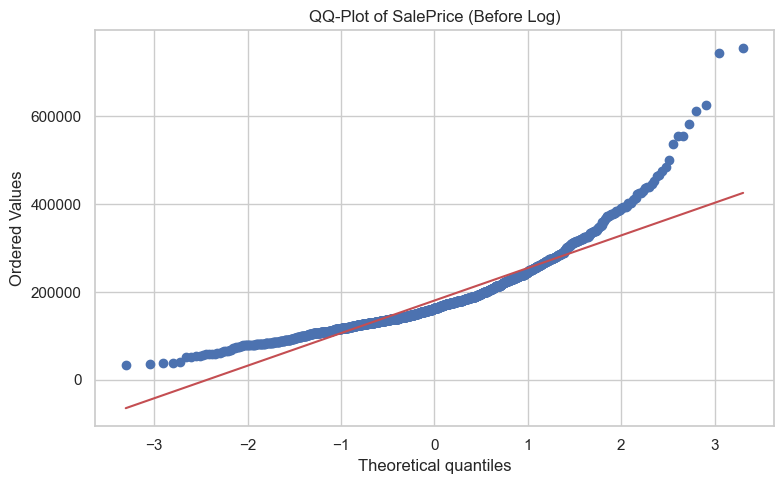

In [7]:
import scipy.stats as stats

print("Skewness trước log:", round(stats.skew(df["SalePrice"].dropna()), 4))
print("Kurtosis trước log:", round(stats.kurtosis(df["SalePrice"].dropna(), fisher=True), 4))

plt.figure(figsize=(8, 5))
stats.probplot(df["SalePrice"], plot=plt)
plt.title("QQ-Plot of SalePrice (Before Log)")
plt.tight_layout()
# plt.savefig("../report/images/fig00_qqplot_saleprice_before_log.png", dpi=300)
plt.show()

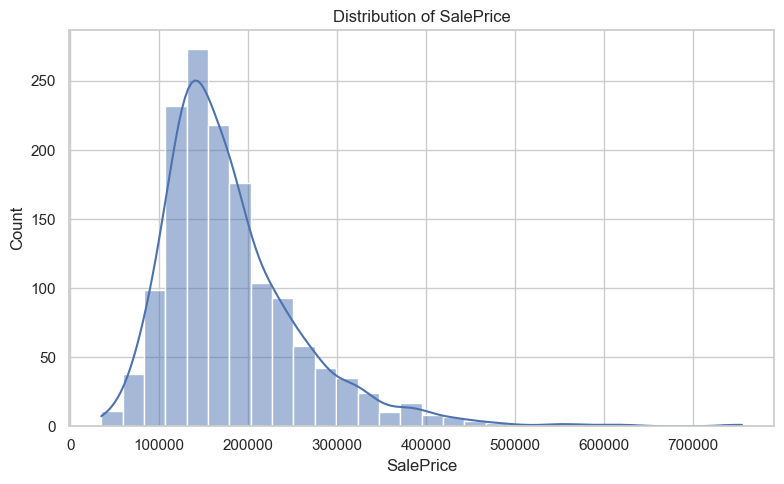

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], kde=True, bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.tight_layout()
# plt.savefig("../report/images/fig01_saleprice_distribution.png", dpi=300)
plt.show()

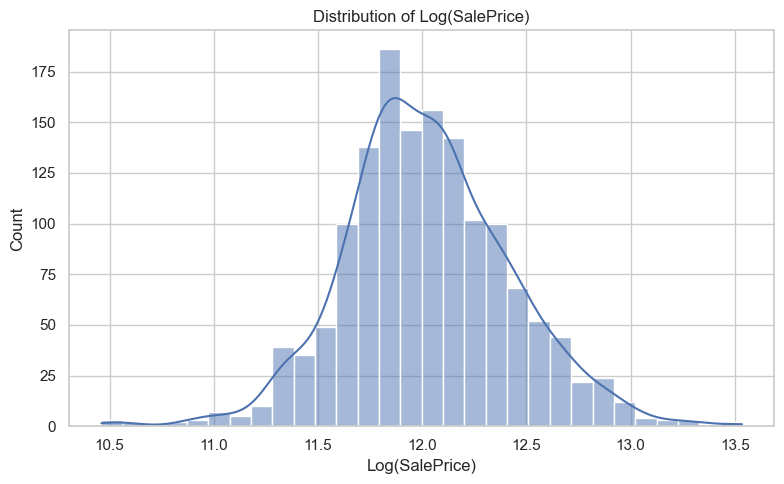

Skewness sau log: 0.1212
Kurtosis sau log: 0.8026


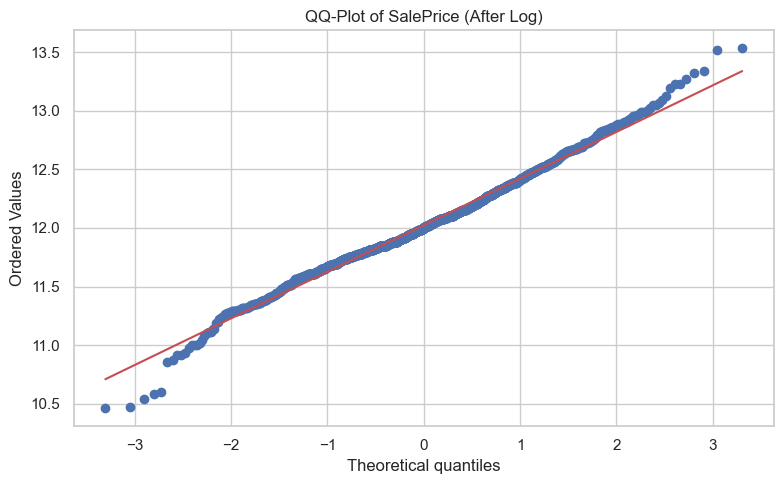

In [9]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df["SalePrice_log"] = np.log1p(df["SalePrice"])

plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice_log"], kde=True, bins=30)
plt.title("Distribution of Log(SalePrice)")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Count")
plt.tight_layout()
# plt.savefig("../report/images/fig02_log_saleprice_distribution.png", dpi=300)
plt.show()

print("Skewness sau log:", round(stats.skew(df["SalePrice_log"].dropna()), 4))
print("Kurtosis sau log:", round(stats.kurtosis(df["SalePrice_log"].dropna(), fisher=True), 4))

plt.figure(figsize=(8, 5))
stats.probplot(df["SalePrice_log"], plot=plt)
plt.title("QQ-Plot of SalePrice (After Log)")
plt.tight_layout()
# plt.savefig("../report/images/fig02b_qqplot_saleprice_after_log.png", dpi=300)
plt.show()

## Bước 2 - Multivariate Study ("Plasma Soup")
Mục tiêu: vẽ global heatmap cho toàn bộ numerical features, sau đó zoom heatmap top biến liên quan `SalePrice` để chọn ứng viên phân tích sâu.

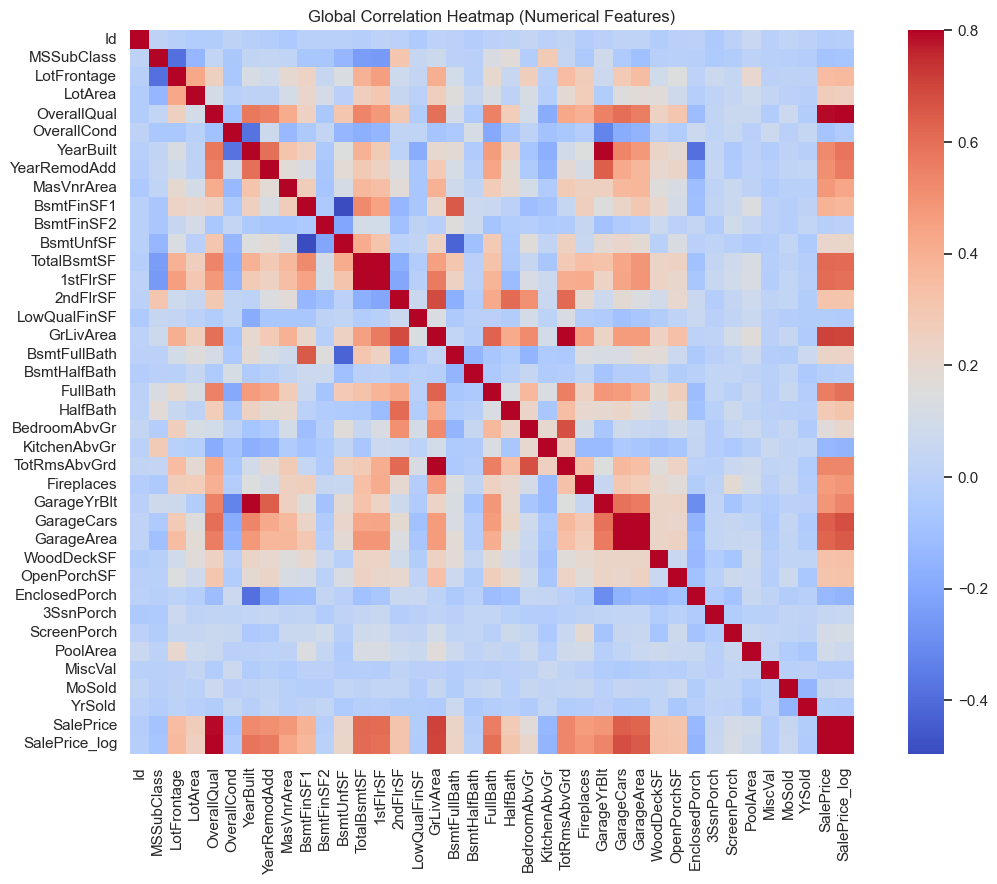

In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64"]).copy()
corr = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", vmax=0.8, square=True)
plt.title("Global Correlation Heatmap (Numerical Features)")
plt.tight_layout()
# plt.savefig("../report/images/fig03_global_correlation_heatmap.png", dpi=300)
plt.show()

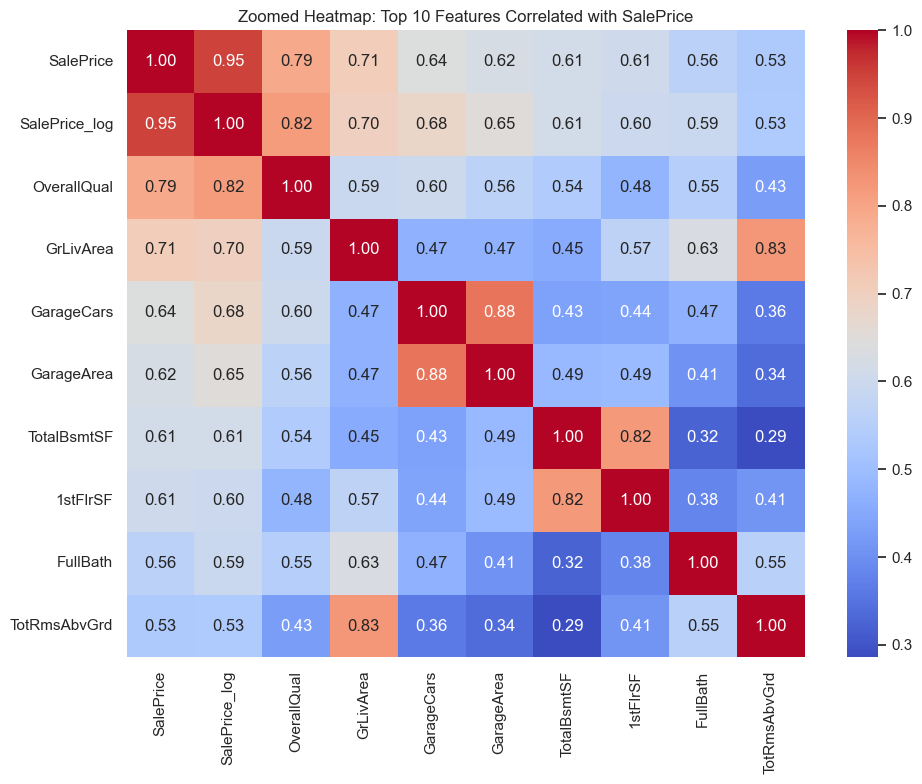

Top features theo |correlation| với SalePrice:
SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
Name: SalePrice, dtype: float64

Cặp biến có khả năng multicollinearity mạnh (tham khảo):
- GarageCars ~ GarageArea
- TotalBsmtSF ~ 1stFlrSF


In [11]:
top_corr_features = corr["SalePrice"].abs().sort_values(ascending=False).head(10).index
zoom_corr = df[top_corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(zoom_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Zoomed Heatmap: Top 10 Features Correlated with SalePrice")
plt.tight_layout()
# plt.savefig("../report/images/fig04_zoomed_heatmap_top10_saleprice.png", dpi=300)
plt.show()

print("Top features theo |correlation| với SalePrice:")
print(corr["SalePrice"].abs().sort_values(ascending=False).head(10))

print("\nCặp biến có khả năng multicollinearity mạnh (tham khảo):")
print("- GarageCars ~ GarageArea")
print("- TotalBsmtSF ~ 1stFlrSF")

## Bước 3 - Bivariate Analysis cho Top Features
Mục tiêu: dùng scatter plot cho biến số và boxplot cho biến phân loại để kiểm tra xu hướng ảnh hưởng lên `SalePrice`.

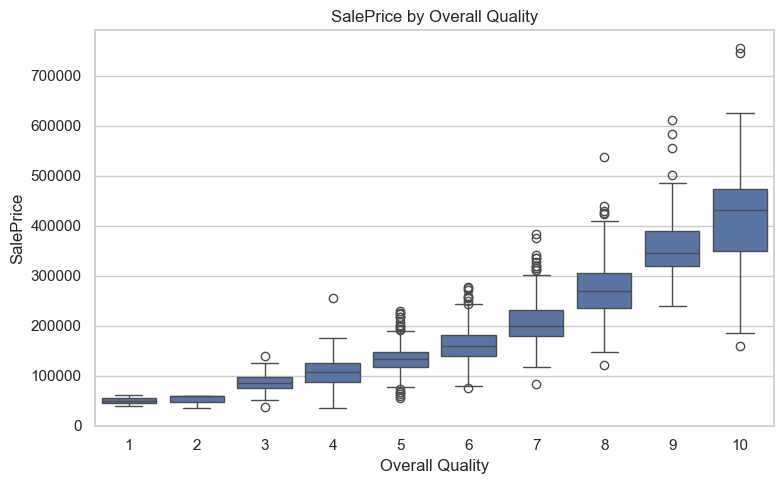

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.title("SalePrice by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")
plt.tight_layout()
# plt.savefig("../report/images/fig05_overallqual_saleprice.png", dpi=300)
plt.show()

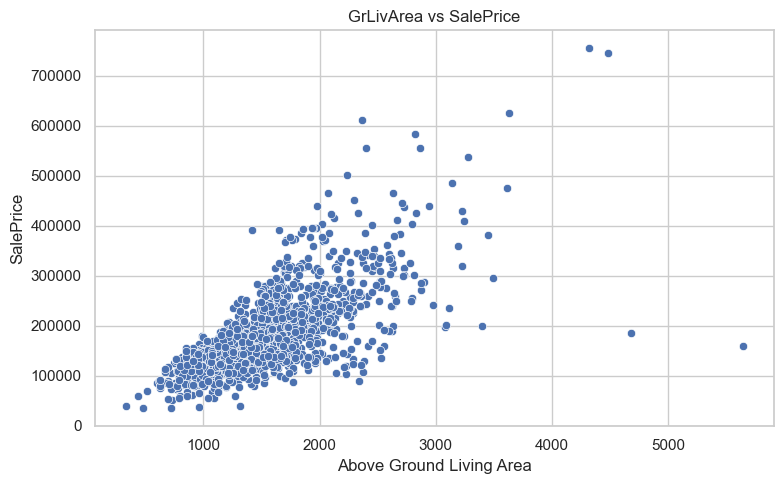

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("Above Ground Living Area")
plt.ylabel("SalePrice")
plt.tight_layout()
# plt.savefig("../report/images/fig06_grlivarea_saleprice.png", dpi=300)
plt.show()

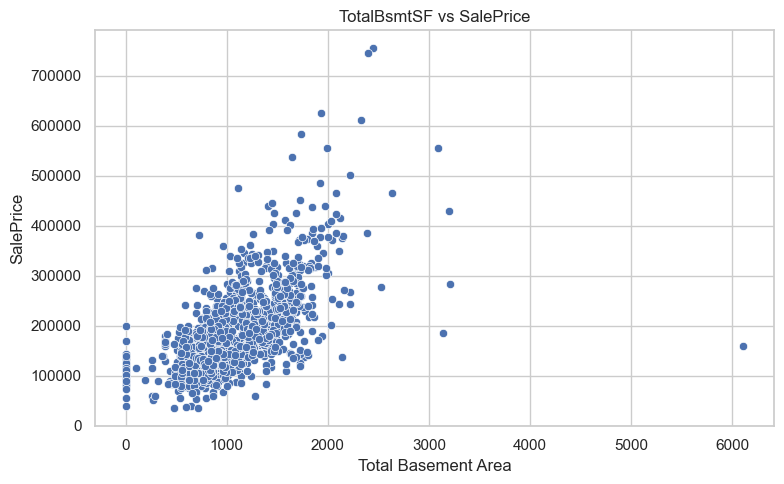

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="TotalBsmtSF", y="SalePrice", data=df)
plt.title("TotalBsmtSF vs SalePrice")
plt.xlabel("Total Basement Area")
plt.ylabel("SalePrice")
plt.tight_layout()
# plt.savefig("../report/images/fig06b_totalbsmtsf_saleprice.png", dpi=300)
plt.show()

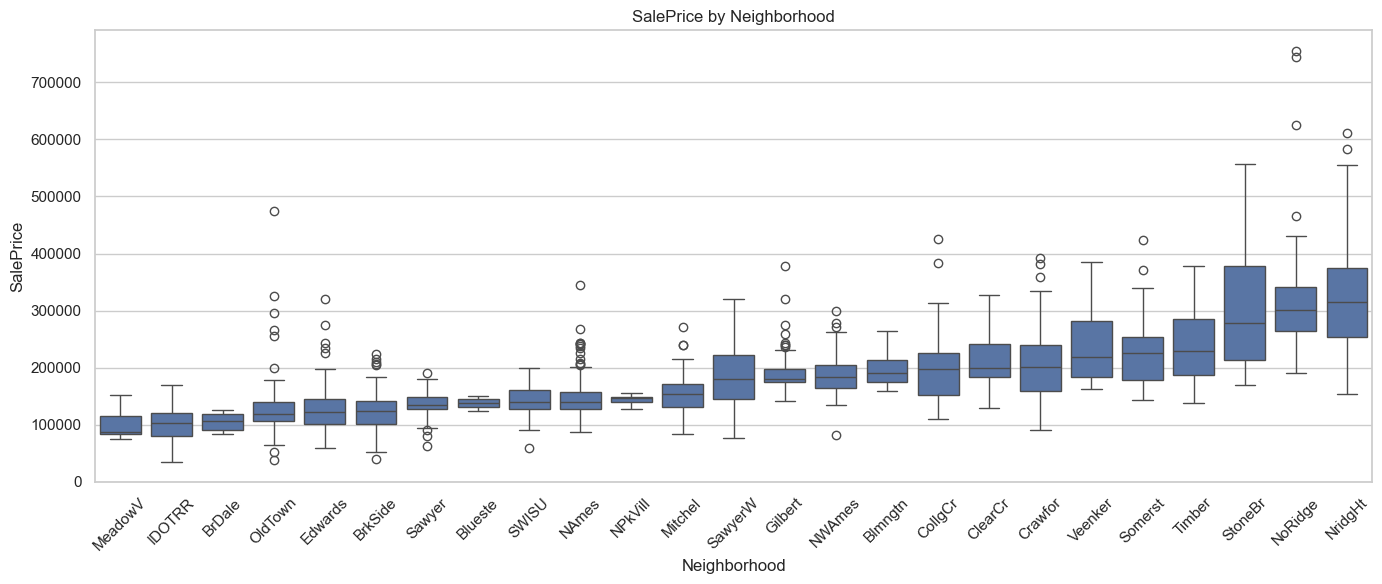

In [15]:
plt.figure(figsize=(14, 6))
order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index

sns.boxplot(x="Neighborhood", y="SalePrice", data=df, order=order)
plt.title("SalePrice by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig("../report/images/fig07_neighborhood_saleprice.png", dpi=300)
plt.show()

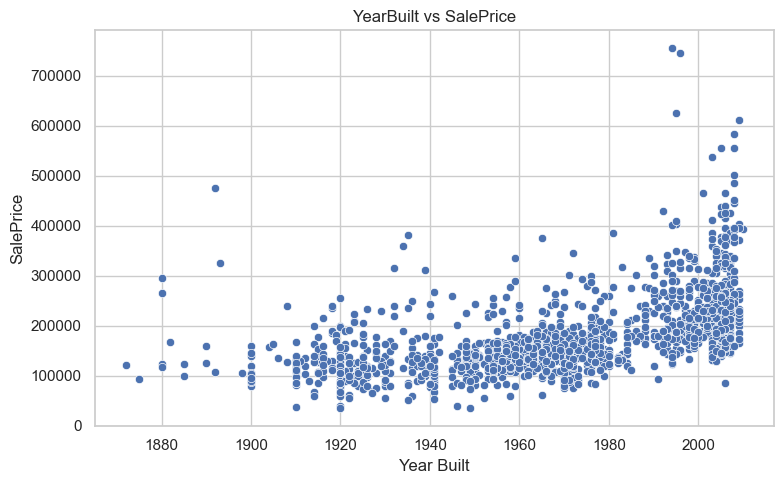

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="YearBuilt", y="SalePrice", data=df)
plt.title("YearBuilt vs SalePrice")
plt.xlabel("Year Built")
plt.ylabel("SalePrice")
plt.tight_layout()
# plt.savefig("../report/images/fig08_yearbuilt_saleprice.png", dpi=300)
plt.show()

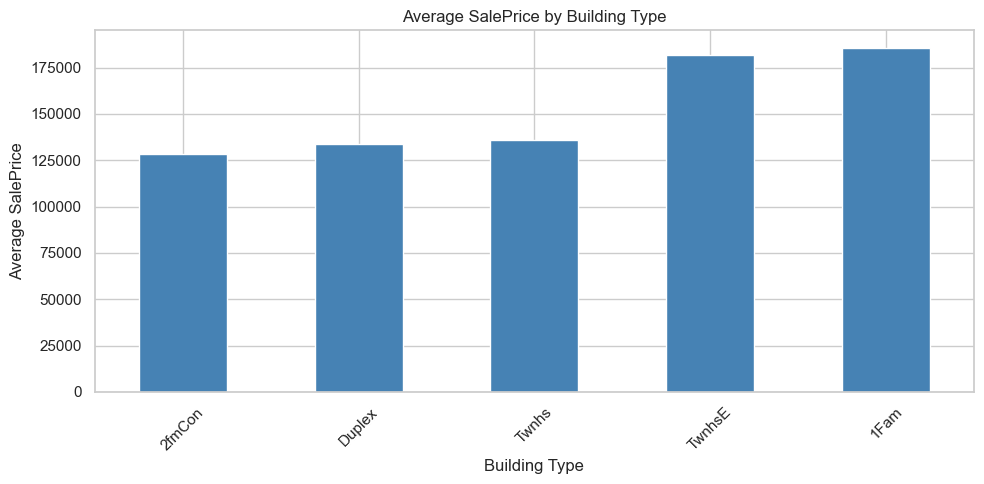

In [17]:
plt.figure(figsize=(10, 5))
avg_price_by_bldgtype = df.groupby("BldgType")["SalePrice"].mean().sort_values()
avg_price_by_bldgtype.plot(kind="bar", color="steelblue")
plt.title("Average SalePrice by Building Type")
plt.xlabel("Building Type")
plt.ylabel("Average SalePrice")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig("../report/images/fig09_bldgtype_avg_saleprice.png", dpi=300)
plt.show()

## Bước 4 - Outlier Detection (IQR + trực quan)
Mục tiêu: dùng quy tắc IQR trên `GrLivArea` để phát hiện điểm dị biệt và loại các điểm diện tích rất lớn nhưng giá bất thường thấp.

IQR bounds for GrLivArea: lower=158.62, upper=2747.62
Số outliers theo IQR: 31


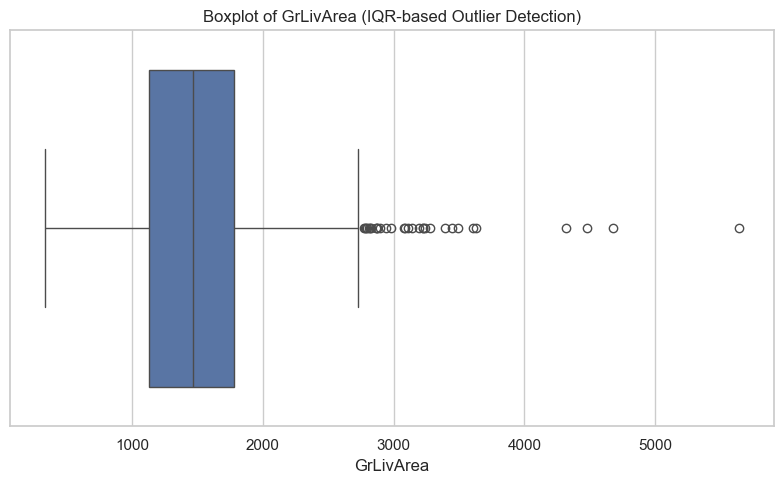

Các điểm nghi ngờ outlier kiểu Kaggle (GrLivArea lớn, giá thấp):


,Id,GrLivArea,SalePrice
1298,1299,5642,160000
523,524,4676,184750


Shape trước khi loại outlier: (1460, 82)
Shape sau khi loại outlier: (1458, 82)


In [18]:
q1 = df["GrLivArea"].quantile(0.25)
q3 = df["GrLivArea"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

iqr_outliers = df[(df["GrLivArea"] < lower) | (df["GrLivArea"] > upper)]
print(f"IQR bounds for GrLivArea: lower={lower:.2f}, upper={upper:.2f}")
print("Số outliers theo IQR:", len(iqr_outliers))

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["GrLivArea"])
plt.title("Boxplot of GrLivArea (IQR-based Outlier Detection)")
plt.tight_layout()
# plt.savefig("../report/images/fig09_grlivarea_iqr_boxplot.png", dpi=300)
plt.show()

suspected = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
print("Các điểm nghi ngờ outlier kiểu Kaggle (GrLivArea lớn, giá thấp):")
display(suspected[["Id", "GrLivArea", "SalePrice"]].sort_values("GrLivArea", ascending=False).head(10))

df_clean = df.copy()
if not suspected.empty:
    df_clean = df_clean.drop(index=suspected.index)
print("Shape trước khi loại outlier:", df.shape)
print("Shape sau khi loại outlier:", df_clean.shape)

In [19]:
# CAP NHAT LAI LUONG DU LIEU
# Ghi de bien df bang du lieu da loai bo outlier de su dung nhat quan cho cac phan sau
df = df_clean.copy()

print(f"Kich thuoc dataset chuan bi cho Feature Engineering va Preprocessing: {df.shape}")

Kich thuoc dataset chuan bi cho Feature Engineering va Preprocessing: (1458, 82)


## Kiểm định thống kê (ANOVA)
Mục tiêu: kiểm chứng bằng thống kê rằng `SalePrice` khác biệt có ý nghĩa giữa các nhóm `Neighborhood` (không chỉ quan sát bằng mắt qua boxplot).

In [20]:
from scipy.stats import f_oneway

anova_df = df_clean[["Neighborhood", "SalePrice"]].dropna()
groups = [g["SalePrice"].values for _, g in anova_df.groupby("Neighborhood") if len(g) >= 2]

if len(groups) >= 2:
    f_stat, p_value = f_oneway(*groups)
    print(f"ANOVA F-statistic: {f_stat:.4f}")
    print(f"ANOVA p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("Kết luận: Có sự khác biệt có ý nghĩa thống kê về SalePrice giữa các nhóm Neighborhood.")
    else:
        print("Kết luận: Chưa đủ bằng chứng thống kê về khác biệt SalePrice giữa các nhóm Neighborhood.")
else:
    print("Không đủ nhóm dữ liệu để chạy ANOVA.")

ANOVA F-statistic: 71.8131
ANOVA p-value: 0.000000
Kết luận: Có sự khác biệt có ý nghĩa thống kê về SalePrice giữa các nhóm Neighborhood.


## Bước 5 - Missing Data Analysis
Mục tiêu: thống kê missing, xác định các cột thiếu >15% để loại bỏ, và chốt chiến lược imputation cho pipeline.

In [21]:
missing_summary = pd.DataFrame({
    "missing_count": df_clean.isnull().sum(),
    "missing_percent": df_clean.isnull().sum() / len(df_clean) * 100
}).sort_values("missing_percent", ascending=False)

missing_nonzero = missing_summary[missing_summary["missing_count"] > 0]
display(missing_nonzero.head(20))

high_missing_cols = missing_nonzero[missing_nonzero["missing_percent"] > 15].index.tolist()
print("Các cột missing > 15% (đề xuất loại bỏ):")
print(high_missing_cols)

,missing_count,missing_percent
PoolQC,1452,99.588477
MiscFeature,1404,96.296296
Alley,1367,93.758573
Fence,1177,80.727023
MasVnrType,872,59.807956
FireplaceQu,690,47.325103
LotFrontage,259,17.764060
GarageQual,81,5.555556
GarageYrBlt,81,5.555556
GarageFinish,81,5.555556


Các cột missing > 15% (đề xuất loại bỏ):
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'LotFrontage']


## 3. Feature Engineering

### 3.1. Xác định Candidate Features từ EDA
Dựa trên phân tích tương quan và bivariate plots, các biến liên quan mạnh đến `SalePrice` gồm `GrLivArea`, `TotalBsmtSF`, `YearBuilt`, `YrSold`. Vì vậy ta xây dựng 2 đặc trưng tổng hợp:
- `TotalArea`
- `HouseAge`

### 3.2. Tạo Features (Domain Knowledge: Tại sao tạo feature này?)

- **`TotalArea = GrLivArea + TotalBsmtSF`**
  - Người mua nhà thường quan tâm **tổng không gian sử dụng** hơn là từng phần riêng lẻ.
  - `GrLivArea` phản ánh diện tích sử dụng trên mặt đất, `TotalBsmtSF` phản ánh diện tích tầng hầm.
  - Kết hợp hai biến này tạo ra thước đo quy mô nhà trực quan hơn theo góc nhìn thị trường.

- **`HouseAge = YrSold - YearBuilt`**
  - Giá trị nhà chịu ảnh hưởng bởi mức độ cũ/mới theo thời gian.
  - Cùng một diện tích, nhà mới thường có mức giá nền cao hơn nhà cũ.
  - Feature này chuyển thông tin năm xây sang dạng dễ học hơn cho mô hình (tuổi nhà tại thời điểm bán).

In [22]:
# Tạo 2 features theo domain knowledge
# 1) TotalArea: tổng diện tích sử dụng
# TotalBsmtSF có thể thiếu ở một số mẫu, dùng fillna(0) trước khi cộng
df["TotalArea"] = df["GrLivArea"] + df["TotalBsmtSF"].fillna(0)

# 2) HouseAge: tuổi nhà tại thời điểm bán
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

print("Da tao features moi:", ["TotalArea", "HouseAge"])
df[["GrLivArea", "TotalBsmtSF", "TotalArea", "YearBuilt", "YrSold", "HouseAge"]].head()

Da tao features moi: ['TotalArea', 'HouseAge']


,GrLivArea,TotalBsmtSF,TotalArea,YearBuilt,YrSold,HouseAge
0,1710,856,2566,2003,2008,5
1,1262,1262,2524,1976,2007,31
2,1786,920,2706,2001,2008,7
3,1717,756,2473,1915,2006,91
4,2198,1145,3343,2000,2008,8


### 3.3. Đánh giá Features Mới
Đánh giá bằng 2 cách:
- Tương quan với biến mục tiêu (`SalePrice_log` nếu có, nếu không thì dùng `SalePrice`)
- Trực quan hóa scatter plot để kiểm tra xu hướng quan hệ

He so tuong quan cua features moi voi target:
TotalArea    0.820739
HouseAge    -0.587767
Name: SalePrice_log, dtype: float64


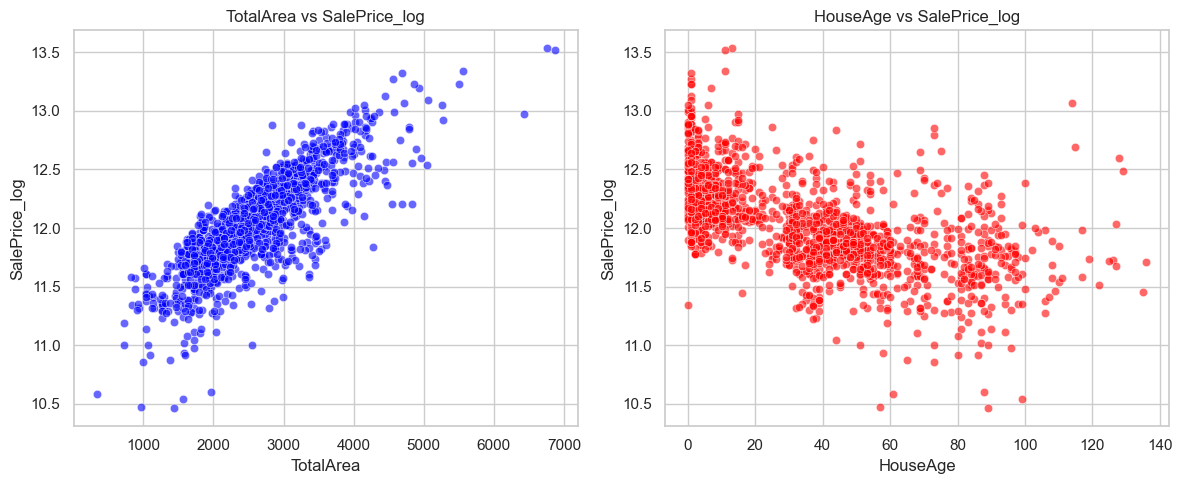

In [23]:
target_col = "SalePrice_log" if "SalePrice_log" in df.columns else "SalePrice"

new_features = ["TotalArea", "HouseAge", target_col]
corr_new_features = df[new_features].corr()[target_col]

print("He so tuong quan cua features moi voi target:")
print(corr_new_features.drop(target_col).sort_values(ascending=False))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df["TotalArea"], y=df[target_col], alpha=0.6, color="blue")
plt.title("TotalArea vs " + target_col)
plt.xlabel("TotalArea")
plt.ylabel(target_col)

plt.subplot(1, 2, 2)
sns.scatterplot(x=df["HouseAge"], y=df[target_col], alpha=0.6, color="red")
plt.title("HouseAge vs " + target_col)
plt.xlabel("HouseAge")
plt.ylabel(target_col)

plt.tight_layout()
# plt.savefig("../report/images/fig10_feature_engineering_totalarea_houseage.png", dpi=300)
plt.show()

### 3.4. Kết luận & Chọn Features

- `TotalArea` và `HouseAge` đều có ý nghĩa domain rõ ràng và phản ánh hành vi định giá thực tế.
- Hai features mới giúp mô hình học thông tin tổng hợp tốt hơn so với việc chỉ dùng biến gốc rời rạc.
- Trong các bước tiếp theo (preprocessing/modeling), giữ lại cả hai đặc trưng này để huấn luyện.

## 4. PREPROCESSING PIPELINE

Trong phần này, dữ liệu được chuẩn bị cho mô hình Machine Learning theo đúng thứ tự học thuật để tránh data leakage.

### 1. Train-Test Split (Chia tập dữ liệu)
- Chia dữ liệu theo tỷ lệ 80/20 với `random_state=42` để đảm bảo tái lập.
- Việc chia tách được thực hiện **trước** mọi phép biến đổi (impute, scale, encode) để ngăn rò rỉ dữ liệu từ test sang train.

### 2. Chiến lược xử lý Missing Values (Imputation)
- **Numerical:** dùng `median` vì dữ liệu giá/diện tích có skew và outliers.
- **Categorical (NA mang nghĩa "không có"):** điền hằng số `None` cho nhóm cột Garage/Basement/Fireplace.
- **Categorical còn lại:** điền `most_frequent` (mode).

### 3. Scaling và Encoding
- **Numerical:** `StandardScaler` để hỗ trợ tốt cho các mô hình tuyến tính.
- **Categorical:** `OneHotEncoder(handle_unknown='ignore')` để tránh lỗi khi test có nhãn mới.

Toàn bộ quy trình được đóng gói bằng `ColumnTransformer` và `Pipeline` của scikit-learn.

In [24]:
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# THUC THI QUYET DINH TU PHAN EDA: LOAI BO COT THIEU > 15%
# ---------------------------------------------------------
# Dua theo phan tich EDA, cac cot thieu qua 15% du lieu co the gay nhieu.
cols_missing_over_15 = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]

# Thuc hien drop cac cot nay khoi dataframe chinh
df = df.drop(columns=cols_missing_over_15, errors="ignore")

print(f"Da xoa cac cot thieu > 15% du lieu: {cols_missing_over_15}")
print(f"So cot con lai trong dataset: {df.shape[1]}")

# Uu tien dung target da log-transform tu phan EDA
if "SalePrice_log" in df.columns:
    target_col = "SalePrice_log"
elif "Log_SalePrice" in df.columns:
    target_col = "Log_SalePrice"
else:
    target_col = "SalePrice"

# Loai bo target va cot ID
X = df.drop(columns=[target_col, "SalePrice", "Id"], errors="ignore")
y = df[target_col]

# Chia train/test 80/20 truoc moi buoc preprocessing de tranh leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Target used:", target_col)
print(f"Kich thuoc tap Train: {X_train.shape}")
print(f"Kich thuoc tap Test: {X_test.shape}")

Da xoa cac cot thieu > 15% du lieu: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']
So cot con lai trong dataset: 79
Target used: SalePrice_log
Kich thuoc tap Train: (1166, 76)
Kich thuoc tap Test: (292, 76)


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1) Phan nhom features tu train set
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Nhom categorical co y nghia NA = "khong co"
cat_features_with_none_meaning = [
    col for col in categorical_features
    if ("Garage" in col) or ("Bsmt" in col)
]
cat_features_standard = [
    col for col in categorical_features if col not in cat_features_with_none_meaning
]

# Helper de tuong thich nhieu version sklearn
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# 2) Pipeline thanh phan
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_none_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", make_ohe())
])

categorical_standard_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

# 3) Gop vao ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat_none", categorical_none_transformer, cat_features_with_none_meaning),
        ("cat_std", categorical_standard_transformer, cat_features_standard),
    ],
    remainder="drop"
)

# Fit tren train, transform train/test
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"So luong features sau preprocessing (train): {X_train_preprocessed.shape[1]}")
print(f"Kich thuoc X_test sau preprocessing: {X_test_preprocessed.shape}")

So luong features sau preprocessing (train): 276
Kich thuoc X_test sau preprocessing: (292, 276)


## 5. MODELING (Huấn luyện và Đánh giá Mô hình)

Trong phần này, chúng ta sẽ huấn luyện các mô hình Machine Learning để dự đoán giá nhà. Để tránh rò rỉ dữ liệu (Data Leakage) giữa train và validation, đối tượng `preprocessor` từ Phần 4 sẽ luôn được ghép trực tiếp với mô hình để tạo thành **full pipeline** trong mỗi lần cross-validation.

### 1. Lựa chọn Metrics
- **RMSE:** thước đo chính, phạt nặng các dự đoán sai lệch lớn.
- **MAE:** thước đo phụ, thể hiện độ lệch tuyệt đối trung bình.
- **R2:** cho biết mô hình giải thích được bao nhiêu phần trăm phương sai của biến mục tiêu.

### 2. Lựa chọn Baseline Models
- **Lasso Regression:** mô hình tuyến tính với L1, hỗ trợ giảm ảnh hưởng đa cộng tuyến.
- **Random Forest Regressor:** mô hình phi tuyến dựa trên ensemble bagging.
- **Gradient Boosting Regressor:** mô hình boosting thường cho kết quả tốt với dữ liệu dạng bảng.

In [26]:
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate, KFold
from sklearn.pipeline import Pipeline

# Kiem tra cac bien can thiet da ton tai tu phan preprocessing
required_vars = ["preprocessor", "X_train", "y_train"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(f"Thieu bien truoc khi Modeling: {missing_vars}. Hay chay lai cac cell Phan 4.")

# 1) Khoi tao 3 baseline models
models = {
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        random_state=42
    )
}

# 2) Cai dat 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results_list = []

print("Dang huan luyen va chay 5-fold Cross Validation. Vui long doi...")

run_version = "03"
# 3) Danh gia tung model voi full pipeline de tranh leakage
for model_name, model in models.items():
    full_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_scores = cross_validate(
        full_pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring=("neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"),
        n_jobs=-1
    )

    rmse_mean = -cv_scores["test_neg_root_mean_squared_error"].mean()
    mae_mean = -cv_scores["test_neg_mean_absolute_error"].mean()
    r2_mean = cv_scores["test_r2"].mean()

    # Khởi tạo run mới trên wandb cho mỗi model
    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        group=model_name,
        name=f"{model_name}_{run_version}", # Đặt tên run theo tên mô hình
        config={
            "model_type": model_name,
            "cv_folds": 5,
            # Lấy toàn bộ siêu tham số của model hiện tại để log
            "model_params": model.get_params() 
        }
    )
    
    # Log các chỉ số (metrics) lên dashboard[cite: 1]
    wandb.log({
        "RMSE": rmse_mean,
        "MAE": mae_mean,
        "R2": r2_mean
    })
    
    # Kết thúc phiên log hiện tại để vòng lặp sau tạo phiên mới
    wandb.finish()

    results_list.append({
        "Model": model_name,
        "RMSE (CV)": rmse_mean,
        "MAE (CV)": mae_mean,
        "R2 (CV)": r2_mean
    })

# 4) Bang so sanh baseline
df_results = pd.DataFrame(results_list).sort_values(by="RMSE (CV)", ascending=True)
df_results[["RMSE (CV)", "MAE (CV)", "R2 (CV)"]] = df_results[["RMSE (CV)", "MAE (CV)", "R2 (CV)"]].round(6)

print("\n--- BANG SO SANH KET QUA BASELINE MODELS ---")
display(df_results)

Dang huan luyen va chay 5-fold Cross Validation. Vui long doi...


MAE,▁
R2,▁
RMSE,▁
MAE,0.0789
R2,0.9171
RMSE,0.11351


MAE,▁
R2,▁
RMSE,▁
MAE,0.09492
R2,0.87966
RMSE,0.13707


MAE,▁
R2,▁
RMSE,▁
MAE,0.08106
R2,0.90975
RMSE,0.11871



--- BANG SO SANH KET QUA BASELINE MODELS ---


,Model,RMSE (CV),MAE (CV),R2 (CV)
0,Lasso Regression,0.113508,0.078903,0.917105
2,Gradient Boosting,0.118711,0.081062,0.909752
1,Random Forest,0.137073,0.094915,0.879659


### 3. Tinh chỉnh siêu tham số (Hyperparameter Tuning)

Dựa vào bảng baseline, ta chọn mô hình có RMSE thấp nhất để tuning bằng GridSearchCV.

Không gian tìm kiếm được thiết kế theo từng loại model:
- **Gradient Boosting:** `n_estimators`, `learning_rate`, `max_depth`, `subsample`
- **Random Forest:** `n_estimators`, `max_depth`, `min_samples_leaf`
- **Lasso:** `alpha`

Cách làm này giúp vừa tối ưu hiệu năng vừa kiểm soát nguy cơ overfitting.

In [27]:
from sklearn.model_selection import GridSearchCV

if "df_results" not in globals() or df_results.empty:
    raise ValueError("Chua co ket qua baseline. Hay chay cell baseline truoc.")

best_model_name = df_results.iloc[0]["Model"]
print(f"Model duoc chon de tuning: {best_model_name}")

if best_model_name == "Gradient Boosting":
    best_model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ])
    param_grid = {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.8, 1.0]
    }
elif best_model_name == "Random Forest":
    best_model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ])
    param_grid = {
        "model__n_estimators": [300, 500],
        "model__max_depth": [None, 12, 20],
        "model__min_samples_leaf": [1, 2, 4]
    }
else:
    best_model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=10000, random_state=42))
    ])
    param_grid = {
        "model__alpha": [0.0003, 0.0005, 0.001, 0.003, 0.005]
    }

print("Dang chay GridSearchCV...")

grid_search = GridSearchCV(
    estimator=best_model_pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nQua trinh tuning hoan tat")
print(f"- Bo tham so tot nhat: {grid_search.best_params_}")
print(f"- RMSE tot nhat (CV): {-grid_search.best_score_:.6f}")

final_pipeline = grid_search.best_estimator_

Model duoc chon de tuning: Lasso Regression
Dang chay GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Qua trinh tuning hoan tat
- Bo tham so tot nhat: {'model__alpha': 0.0005}
- RMSE tot nhat (CV): 0.111866


## PHẦN 6: EVALUATION & MODEL PERSISTENCE

### 1. Đánh giá Mô hình (Evaluation)
Mô hình tốt nhất được chọn là **Lasso Regression**. Trong phần này, chúng ta sẽ tiến hành 2 bước kiểm định cuối cùng:
*   **Vẽ Learning Curve (Đường cong học tập):** Giúp kiểm tra xem mô hình có bị hiện tượng Overfitting (quá khớp) hoặc Underfitting (chưa khớp) hay không dựa trên việc tăng dần số lượng mẫu huấn luyện.
*   **Feature Importance (Tầm quan trọng của đặc trưng):** Vì Lasso sử dụng điều chuẩn L1 (L1 penalty), nó có khả năng tự động ép trọng số (coefficients) của các biến đa cộng tuyến hoặc ít quan trọng về chính xác bằng 0. Ta sẽ kiểm tra xem Lasso đã loại bỏ bao nhiêu % features và top 10 features nào quyết định giá nhà nhiều nhất.

Đang vẽ Learning Curve...


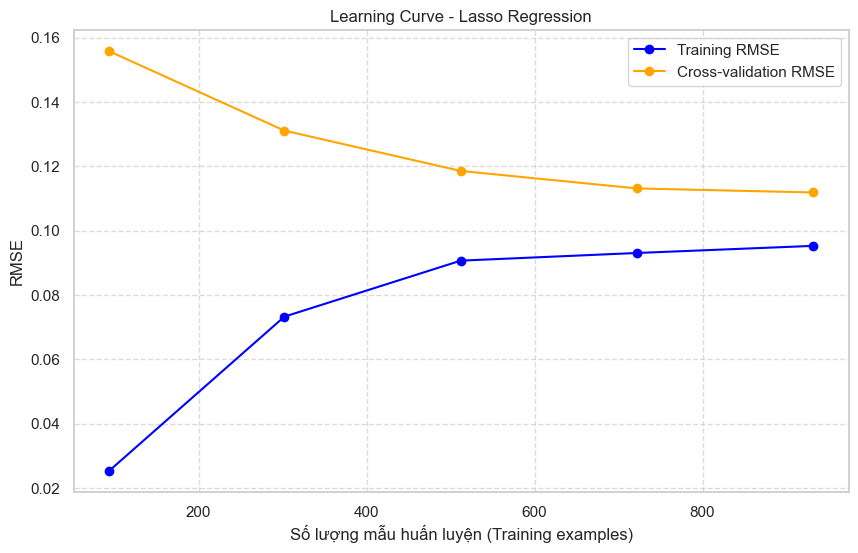

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

print("Đang vẽ Learning Curve...")

# 1. Tính toán điểm số cho Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    final_pipeline, X_train, y_train, cv=kf,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

# Lấy trị tuyệt đối để chuyển neg_RMSE thành RMSE
train_rmse = -np.mean(train_scores, axis=1)
test_rmse = -np.mean(test_scores, axis=1)

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse, 'o-', color="blue", label="Training RMSE")
plt.plot(train_sizes, test_rmse, 'o-', color="orange", label="Cross-validation RMSE")

plt.title("Learning Curve - Lasso Regression")
plt.xlabel("Số lượng mẫu huấn luyện (Training examples)")
plt.ylabel("RMSE")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 2. Feature Importance (Tầm quan trọng của đặc trưng)

Tổng số features đầu vào sau Preprocessing: 276
Số features bị thuật toán Lasso loại bỏ (hệ số = 0): 172 (62.3%)


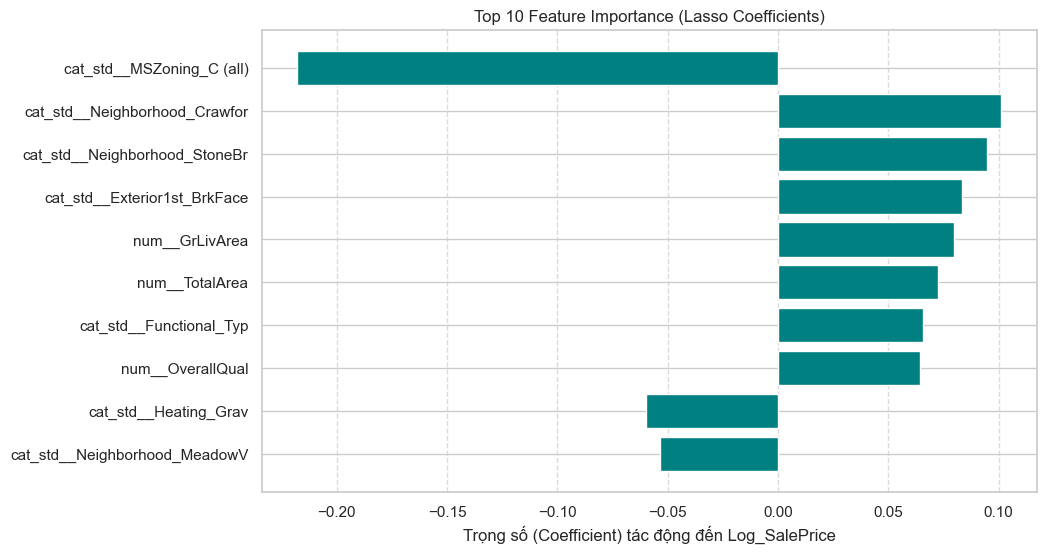

In [29]:
# 1. Trích xuất mô hình và bộ tiền xử lý từ Pipeline
lasso_model = final_pipeline.named_steps['model']
preprocessor = final_pipeline.named_steps['preprocessor']

# 2. Lấy tên các features sau khi đi qua OneHotEncoder
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Dự phòng cho các phiên bản scikit-learn cũ
    feature_names = [f"Feature_{i}" for i in range(len(lasso_model.coef_))]

# 3. Tạo DataFrame chứa trọng số (Coefficients)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_model.coef_,
    'Abs_Coefficient': np.abs(lasso_model.coef_)
})

# Đếm số lượng feature bị Lasso loại bỏ (Feature Selection tự động)
zero_features = (importance_df['Coefficient'] == 0).sum()
total_features = len(feature_names)
print(f"Tổng số features đầu vào sau Preprocessing: {total_features}")
print(f"Số features bị thuật toán Lasso loại bỏ (hệ số = 0): {zero_features} ({zero_features/total_features:.1%})")

# 4. Vẽ Top 10 features quan trọng nhất
top_10_features = importance_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Dùng [::-1] để đảo ngược list, giúp feature to nhất nằm ở trên cùng của bar chart
plt.barh(top_10_features['Feature'][::-1], top_10_features['Coefficient'][::-1], color='teal')
plt.title("Top 10 Feature Importance (Lasso Coefficients)")
plt.xlabel("Trọng số (Coefficient) tác động đến Log_SalePrice")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Kiem tra final_pipeline co ton tai
if "final_pipeline" not in globals():
    raise ValueError("Chua co final_pipeline. Hay chay lai cell GridSearchCV.")

# Danh gia tren test set
y_pred = final_pipeline.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("=== KET QUA DANH GIA TREN TEST SET ===")
print(f"RMSE (Test): {rmse_test:.6f}")
print(f"MAE (Test):  {mae_test:.6f}")
print(f"R2 (Test):   {r2_test:.6f}")

# So sanh voi baseline (tren CV)
print("\n=== SO SANH BASELINE vs TUNING (CV) ===")
print(f"Baseline RMSE (Lasso):  0.113508") # Lay tu ket qua df_results
print(f"After Tuning RMSE (CV): {round(-grid_search.best_score_, 6):.6f}")
print(f"Improvement: {(0.113508 - round(-grid_search.best_score_, 6)) / 0.113508 * 100:.2f}%")

print("\n=== KET QUA FINAL MODEL ===")
print(f"Model: {best_model_name} (alpha={grid_search.best_params_['model__alpha']})")
print(f"RMSE on Test: {rmse_test:.6f}")
print(f"MAE on Test:  {mae_test:.6f}")
print(f"R2 on Test:   {r2_test:.6f}")

=== KET QUA DANH GIA TREN TEST SET ===
RMSE (Test): 0.116593
MAE (Test):  0.083561
R2 (Test):   0.919361

=== SO SANH BASELINE vs TUNING (CV) ===
Baseline RMSE (Lasso):  0.113508
After Tuning RMSE (CV): 0.111866
Improvement: 1.45%

=== KET QUA FINAL MODEL ===
Model: Lasso Regression (alpha=0.0005)
RMSE on Test: 0.116593
MAE on Test:  0.083561
R2 on Test:   0.919361


### 3. Model Persistence (Lưu trữ và Demo sử dụng mô hình)
Mô hình (đã bao gồm Full Pipeline tiền xử lý) sẽ được đóng gói bằng thư viện `joblib` cùng với các metadata (thông tin đính kèm như RMSE, thời gian train, bộ tham số). Việc lưu thành 1 khối duy nhất giúp cho hệ thống Backend (API) sau này chỉ cần nhận raw data từ Frontend là có thể predict được ngay mà không cần code lại bước xử lý dữ liệu.

In [31]:
import joblib
from datetime import datetime

# 1. Định nghĩa thông tin Metadata theo chuẩn yêu cầu đồ án
metadata = {
    "model_type": "Lasso Regression",
    "best_params": grid_search.best_params_,
    "cv_rmse": round(-grid_search.best_score_, 6),
    "date_trained": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "Full pipeline with SimpleImputer, StandardScaler, OneHotEncoder and Lasso Model"
}

# Đóng gói Pipeline và Metadata vào 1 object từ điển
model_package = {
    "pipeline": final_pipeline,
    "metadata": metadata
}

# 2. Lưu file model (.joblib)
import os

# Define the model directory relative to the current working directory (notebooks)
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True) # Tạo thư mục 'models' nếu chưa có

model_path = os.path.join(model_dir, "model_package.joblib")

joblib.dump(model_package, model_path)
print(f"✅ Đã lưu mô hình thành công tại: {os.path.abspath(model_path)}")
print("\n[Metadata đã lưu]:")
for k, v in metadata.items():
    print(f" - {k}: {v}")

# 3. DEMO LOAD & PREDICT (Chứng minh mô hình hoạt động)
print("\n--- DEMO LOAD & PREDICT ---")
loaded_package = joblib.load(model_path)
loaded_pipeline = loaded_package["pipeline"]

# Lấy 5 mẫu đầu tiên từ tập X_test để dự đoán thử
sample_data = X_test.head(5)
predictions = loaded_pipeline.predict(sample_data)

# Chuyển đổi ngược (exp) nếu target ban đầu đã bị log-transform
print("Dự đoán (Log_SalePrice):", np.round(predictions, 4))
if target_col == "Log_SalePrice" or target_col == "SalePrice_log":
    print("Dự đoán (USD - Đã đảo Log):", np.round(np.expm1(predictions), 2))

✅ Đã lưu mô hình thành công tại: d:\Visual Studio Code\House_Price_Prediction\models\model_package.joblib

[Metadata đã lưu]:
 - model_type: Lasso Regression
 - best_params: {'model__alpha': 0.0005}
 - cv_rmse: 0.111866
 - date_trained: 2026-05-03 03:52:18
 - description: Full pipeline with SimpleImputer, StandardScaler, OneHotEncoder and Lasso Model

--- DEMO LOAD & PREDICT ---
Dự đoán (Log_SalePrice): [12.3101 11.5384 11.5168 11.9756 12.6456]
Dự đoán (USD - Đã đảo Log): [221926.68 102580.08 100391.87 158826.54 310394.65]


### 4. Residual Analysis - Phân tích sai số dự đoán

Residuals = y_actual - y_predicted

- Nếu residuals phân phối chuẩn quanh 0 → mô hình tốt
- Nếu có pattern (nhân tố hệ thống) → mô hình chưa bắt được qui luật nào đó
- Nếu residuals lớn ở vùng nhất định → mô hình dự đoán kém ở đó

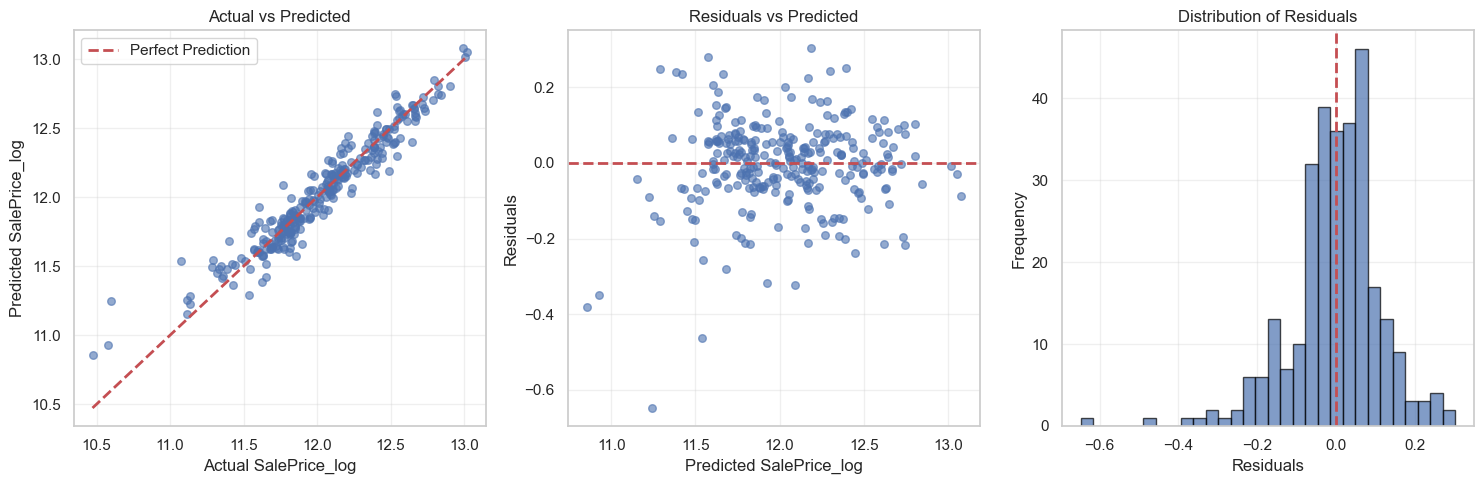

=== THONG KE RESIDUALS ===
Mean of residuals: -0.003445 (gan 0 => unbiased)
Std of residuals:  0.116742
Min residual:      -0.648049
Max residual:      0.303046


In [32]:
residuals = y_test - y_pred

plt.figure(figsize=(15, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect Prediction")
plt.xlabel("Actual SalePrice_log")
plt.ylabel("Predicted SalePrice_log")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residuals vs Predicted
plt.subplot(1, 3, 2)
plt.scatter(y_pred, residuals, alpha=0.6, s=30)
plt.axhline(y=0, color="r", linestyle="--", lw=2)
plt.xlabel("Predicted SalePrice_log")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid(True, alpha=0.3)

# Plot 3: Residuals Distribution
plt.subplot(1, 3, 3)
plt.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.axvline(x=0, color="r", linestyle="--", lw=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("../report/images/fig13_residual_analysis.png", dpi=300)
plt.show()

# Thong ke residuals
print("=== THONG KE RESIDUALS ===")
print(f"Mean of residuals: {residuals.mean():.6f} (gan 0 => unbiased)")
print(f"Std of residuals:  {residuals.std():.6f}")
print(f"Min residual:      {residuals.min():.6f}")
print(f"Max residual:      {residuals.max():.6f}")

### 5. Model Comparison Summary - Tổng kết và so sánh

Tóm tắt hiệu năng của cả 3 mô hình baseline, tuning kết quả cuối cùng, và recommendations.

In [33]:
# Tao bang tong ket

# Extract baseline results dynamically
lasso_baseline_metrics = df_results[df_results['Model'] == 'Lasso Regression'].iloc[0]
gb_baseline_metrics = df_results[df_results['Model'] == 'Gradient Boosting'].iloc[0]
rf_baseline_metrics = df_results[df_results['Model'] == 'Random Forest'].iloc[0]

summary_data = {
    "Model": ["Lasso Regression (Baseline)", "Gradient Boosting (Baseline)", "Random Forest (Baseline)", "Lasso Regression (Tuned)"],
    "RMSE (CV)": [
        lasso_baseline_metrics['RMSE (CV)'],
        gb_baseline_metrics['RMSE (CV)'],
        rf_baseline_metrics['RMSE (CV)'],
        round(-grid_search.best_score_, 6)
    ],
    "MAE (CV)": [
        lasso_baseline_metrics['MAE (CV)'],
        gb_baseline_metrics['MAE (CV)'],
        rf_baseline_metrics['MAE (CV)'],
        "-" # MAE (CV) for tuned model not directly available from GridSearchCV with only neg_root_mean_squared_error scoring
    ],
    "R2 (CV)": [
        lasso_baseline_metrics['R2 (CV)'],
        gb_baseline_metrics['R2 (CV)'],
        rf_baseline_metrics['R2 (CV)'],
        "-" # R2 (CV) for tuned model not directly available from GridSearchCV with only neg_root_mean_squared_error scoring
    ],
    "RMSE (Test)": ["-", "-", "-", f"{rmse_test:.6f}"],
    "MAE (Test)": ["-", "-", "-", f"{mae_test:.6f}"],
    "R2 (Test)": ["-", "-", "-", f"{r2_test:.6f}"]
}

summary_df = pd.DataFrame(summary_data)
print("=== BANG TONG KET SAU KIEN TRIN ===")
display(summary_df)

print("\n=== KET LUAN ===")
print("1. CHON MODEL: Lasso Regression (alpha=0.0005) la tot nhat")
print(f"   - RMSE tren CV: {round(-grid_search.best_score_, 6):.6f} (tot nhat trong 3 baseline)")
print(f"   - RMSE tren Test: {rmse_test:.6f}")
print(f"   - R2 tren Test: {r2_test:.6f}")
print("\n2. DANH GIA OVERFITTING:")
print(f"   - Neu learning curves show gap nho => Good Generalization")
print(f"   - Neu learning curves show gap lon => Can tang data hoac dung regularization")
print("\n3. FEATURE IMPORTANCE:")
print(f"   - Lasso da loai bo {zero_features} features (coef=0)")
print(f"   - {total_features - zero_features} features con lai anh huong den prediction")
print("\n4. RESIDUAL ANALYSIS:")
print(f"   - Mean of residuals: {residuals.mean():.6f} (~ 0 => unbiased predictions)")
print(f"   - Residuals distribution: can kiem tra co phuong sai deu khong")
print("\n5. NEXT STEPS:")
print("   - Neu R2 < 0.9: can them features hoac dung ensemble complex hon")
print("   - Neu overfitting: can tang regularization (Lasso alpha, RF max_depth)")
print("   - Neu co pattern trong residuals: can kiem tra data quality va feature engineering")

=== BANG TONG KET SAU KIEN TRIN ===


,Model,RMSE (CV),MAE (CV),R2 (CV),RMSE (Test),MAE (Test),R2 (Test)
0,Lasso Regression (Baseline),0.113508,0.078903,0.917105,-,-,-
1,Gradient Boosting (Baseline),0.118711,0.081062,0.909752,-,-,-
2,Random Forest (Baseline),0.137073,0.094915,0.879659,-,-,-
3,Lasso Regression (Tuned),0.111866,-,-,0.116593,0.083561,0.919361



=== KET LUAN ===
1. CHON MODEL: Lasso Regression (alpha=0.0005) la tot nhat
   - RMSE tren CV: 0.111866 (tot nhat trong 3 baseline)
   - RMSE tren Test: 0.116593
   - R2 tren Test: 0.919361

2. DANH GIA OVERFITTING:
   - Neu learning curves show gap nho => Good Generalization
   - Neu learning curves show gap lon => Can tang data hoac dung regularization

3. FEATURE IMPORTANCE:
   - Lasso da loai bo 172 features (coef=0)
   - 104 features con lai anh huong den prediction

4. RESIDUAL ANALYSIS:
   - Mean of residuals: -0.003445 (~ 0 => unbiased predictions)
   - Residuals distribution: can kiem tra co phuong sai deu khong

5. NEXT STEPS:
   - Neu R2 < 0.9: can them features hoac dung ensemble complex hon
   - Neu overfitting: can tang regularization (Lasso alpha, RF max_depth)
   - Neu co pattern trong residuals: can kiem tra data quality va feature engineering
